Running Sensitivity Analysis Grid... (This will take 15-30 seconds)


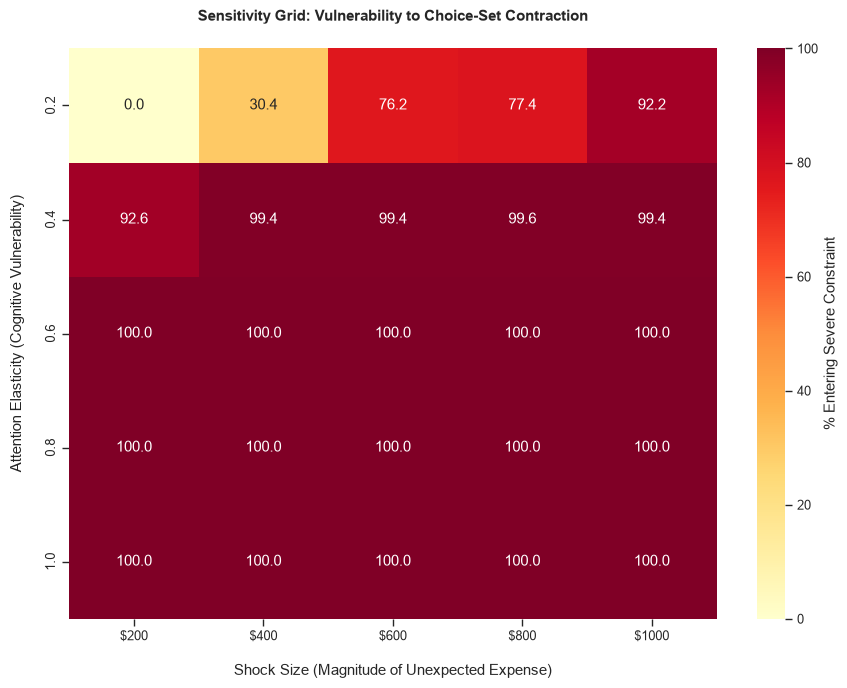

In [1]:
import sys
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))

from src.model.household import Household
from src.model.choice_set import Action, ChoiceSet
from src.model.simulation import Simulation
from src.model.intervention import Intervention

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.1)

universal_actions = [
    Action("Pay in Full", 0.0, 0.1),
    Action("Min Payment", 50.0, 0.2),
    Action("Refinance", 10.0, 0.8),
    Action("Payday Loan", 150.0, 0.1)
]
choice_set = ChoiceSet(universal_actions)

# The grid of parameters we want to test
shock_sizes = [-200, -400, -600, -800, -1000]
sensitivities = [0.2, 0.4, 0.6, 0.8, 1.0]
iterations_per_cell = 500

print("Running Sensitivity Analysis Grid... (This will take 15-30 seconds)")

results_matrix = np.zeros((len(sensitivities), len(shock_sizes)))

for i, sens in enumerate(sensitivities):
    for j, shock in enumerate(shock_sizes):
        severe_constraints = 0
        
        for _ in range(iterations_per_cell):
            seed = random.randint(0, 100000)
            # Standard household to isolate the variables being tested
            hh = Household(1000.0, 5000.0, 1200.0, 1500.0, sens)
            
            # Run without intervention to see baseline vulnerability
            sim = Simulation(hh, choice_set, 12, 0.3, shock, random_seed=seed)
            sim.run()
            
            if sim.household.attention < 0.8:
                severe_constraints += 1
                
        # Calculate percentage of households that became highly constrained
        results_matrix[i, j] = (severe_constraints / iterations_per_cell) * 100

# Plotting the Heatmap
plt.figure(figsize=(9, 7))
ax = sns.heatmap(results_matrix, annot=True, fmt=".1f", cmap="YlOrRd", 
                 xticklabels=[f"${abs(s)}" for s in shock_sizes], 
                 yticklabels=sensitivities, cbar_kws={'label': '% Entering Severe Constraint'})

plt.title("Sensitivity Grid: Vulnerability to Choice-Set Contraction", pad=20, fontweight='bold')
plt.xlabel("Shock Size (Magnitude of Unexpected Expense)", labelpad=15)
plt.ylabel("Attention Elasticity (Cognitive Vulnerability)", labelpad=15)
plt.tight_layout()
plt.show()

A color-coded grid ranging from green to red. This grid maps out the 'danger zone,' showing the exact tipping points where financial stress overwhelms human attention and causes a household to collapse.